In [26]:
# Ensure that modules are reloaded whenever a cell is run to pick up changes to development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# Import Packages
import json
import sys
!{sys.executable} -m pip install plotly polars streamlit rich stqdm watchdog pyomo gurobipy iudex --use-deprecated=legacy-resolver


from gsopt.analysis import *
from gsopt.utils import filter_warnings, get_time_string

filter_warnings() # Supress cartopy warnings

  Using cached stqdm-0.0.5-py3-none-any.whl (11 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 10.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 10.8 MB/s eta 0:00:00a 0:00:01
  Using cached iudex-0.15.4-py3-none-any.whl (46 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached ply-3.11-py2.py3-none-any.whl (49 kB)
  Using cached opentelemetry_contrib_instrumentations-0.48b0-py3-none-any.whl (6.6 kB)
  Using cached opentelemetry_exporter_otlp-1.29.0-py3-none-any.whl (7.0 kB)
  Using cached opentelemetry_instrumentation_alephalpha-0.32.2-py3-none-any.whl (5.1 kB)
  Using cached opentelemetry_instrumentation_anthropic-0.32.2-py3-none-any.whl (9.9 kB)
  Using cached opentelemetry_instrumentation_bedrock-0.32.2-py3-none-any.whl (8.8 kB)
  Using cached opentelemetry_instrumentation_chromadb-0.32.2-py3-none-any.whl (6.3 kB)
  Using cached opentelemetry_instrumentation_cohere-0.32.2-py3-none-any.whl (5.5 kB)
  Using cached

In [36]:
# Load Example Solution

# Single-satellite example
solution_file = '/data/single_sat_solution.json'

# Multi-satellite example
# solution_file = '../data/multi_sat_solution.json'

# Load Solution Data
solution = load_solution(solution_file)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

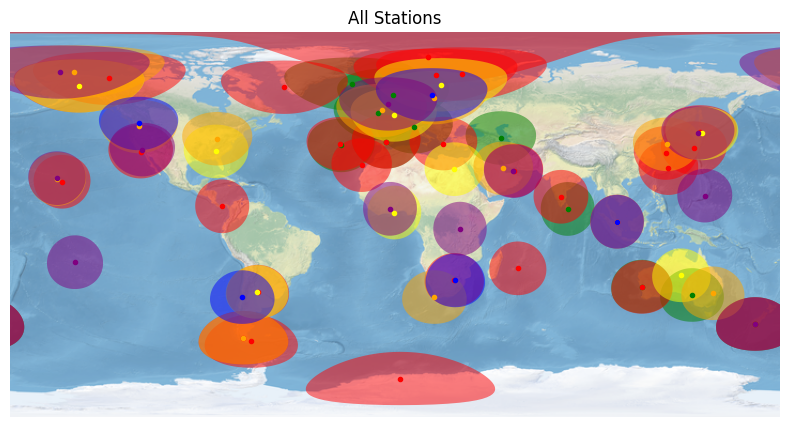

In [4]:
# Plot solution stations
#fig_all_stations, ax_all_stations = plot_solution_stations(solution)
#ax_all_stations.set_title('All Stations');

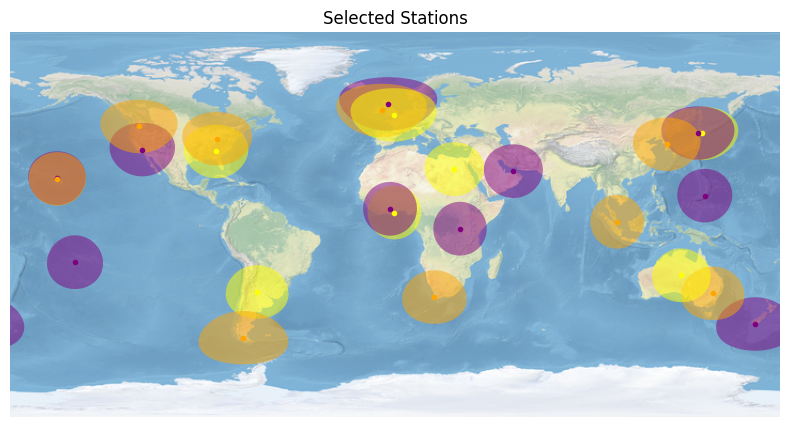

In [5]:
# Plot selected stations
fig_sel_stations, ax_sel_stations = plot_solution_stations(solution, selected_only=True)
ax_sel_stations.set_title('Selected Stations');

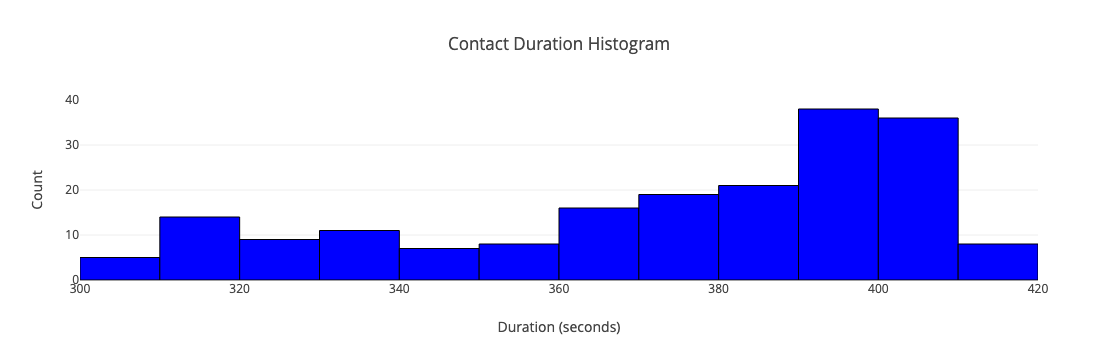

In [6]:
# Contact Analysis
contact_statistics = compute_contact_statistics(solution.contacts)

# Display contact duration histogram
contact_duration_hist = plot_contact_duration_histogram(solution.contacts, units='seconds', x_axis_min=200)
contact_duration_hist.show()

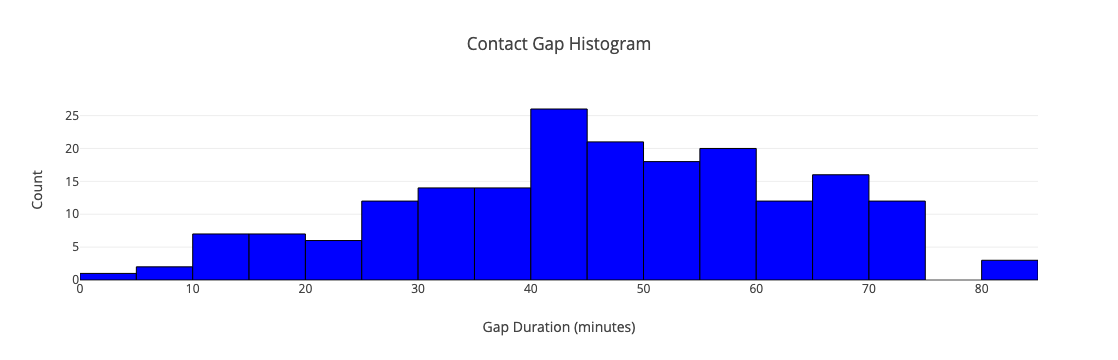

In [7]:
# Gap analysis
contact_gaps = compute_contact_gaps(solution.contacts)
contact_gap_hist = plot_contact_gap_histogram(contact_gaps, units='minutes')
contact_gap_hist.show()

In [8]:
# Compute Gap Statistics
gap_statistics = compute_gap_statistics(contact_gaps['all'])

# Display Gap Statistics
print(f'Number of Gaps:       {gap_statistics["num_gaps"]}')
print(f'Minimum Gap Duration: {get_time_string(gap_statistics["min_gap_duration_s"])}')
print(f'Maximum Gap Duration: {get_time_string(gap_statistics["max_gap_duration_s"])}')
print(f'Mean Gap Duration:    {get_time_string(gap_statistics["mean_gap_duration_s"])}')

Number of Gaps:       191
Minimum Gap Duration: 1 minutes and 56.00 seconds
Maximum Gap Duration: 1 hours, 22 minutes, and 34.00 seconds
Mean Gap Duration:    46 minutes and 10.23 seconds


In [ ]:
analysis = analyze_solution(solution, data_unit=DataUnits.GB)

In [ ]:
print(analysis)

In [ ]:
DataUnits.TB.value